In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

### 데이터 표준화
- 데이터를 표준화하면 학습이 비정상적으로 이루어지는 것을 정상화 할 수 있으며 학습 횟수를 획기적으로 줄일 수 있다.
- 데이터 : 직장인 100명의 연봉과 나이 데이터
- 연봉 : 3000만원 ~ 8000만원
- 나이 : 20 ~ 60
- 문제 : 그대로 그래프를 그리면 '나이'의 변화는 티도 안난다.
- 머신러닝을 수행할 때 학습이 비정상으로 되거나 매우 오래 걸릴 수도 있다.
- Standard Scaler : 각 컬럼의 값들을 평균은 0, 분산을 1로 맞추는 작업. "누가 얼마나 평균에서 떨어져 있는가"
- MinMax Scaler : 각 컬럼의 값들을 0 ~ 1 사이로 압축해서 '최소/최대 대비 어느 위치인가'를 비교

In [2]:
# 데이터를 생성한다.
np.random.seed(42)
n = 100

# 연봉 : 평균 5000만원, 표준편차 1000만원
salary = np.random.normal(loc=50000000, scale=10000000, size=n)
# 나이 : 평균 35세, 표준편차 5세
age = np.random.normal(loc=35,scale=5, size=n)

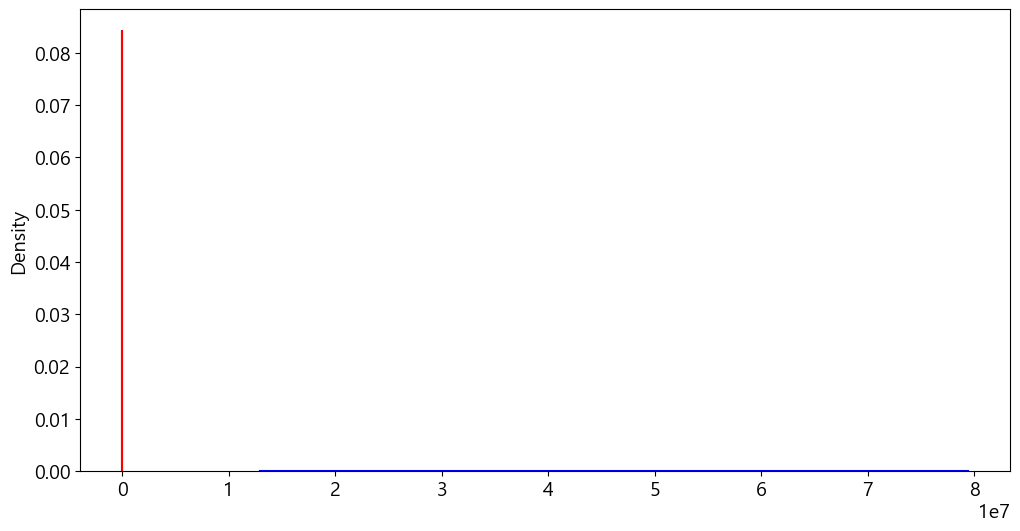

In [3]:
sns.kdeplot(salary, color='blue')
sns.kdeplot(age, color='red')

plt.show()

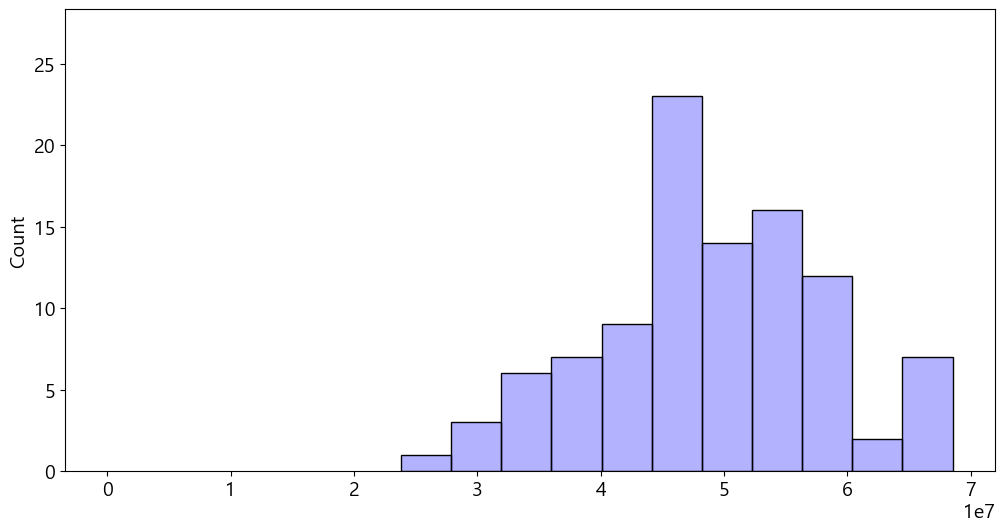

In [4]:
sns.histplot(salary, color='blue', alpha=0.3)
sns.histplot(age, color='red', alpha=0.3)

plt.show()

In [5]:
df = pd.DataFrame({
    'Salary' : salary,
    'Age' : age
})
df

,Salary,Age
0,5.496714e+07,27.923146
1,4.861736e+07,32.896773
2,5.647689e+07,33.286427
3,6.523030e+07,30.988614
4,4.765847e+07,34.193571
...,...,...
95,3.536485e+07,36.926587
96,5.296120e+07,30.580713
97,5.261055e+07,35.768626
98,5.005113e+07,35.291044


In [6]:
# StandardScaler(평균 0, 분산1)
scaler_std = StandardScaler()
a1 = scaler_std.fit_transform(df)

df_std = pd.DataFrame(a1, columns = ['Salary','Age'])
df_std

,Salary,Age
0,0.664619,-1.515115
1,-0.038089,-0.466809
2,0.831697,-0.384681
3,1.800406,-0.868997
4,-0.144206,-0.193479
...,...,...
95,-1.504697,0.382566
96,0.442629,-0.954972
97,0.403824,0.138499
98,0.120582,0.037838


In [7]:
# MinMaxScaler (0 ~ 1 사이로 압축)
scaler_minmax = MinMaxScaler()

a1 = scaler_minmax.fit_transform(df)
df_minmax = pd.DataFrame(a1, columns=['Salary', 'Age'])
df_minmax

,Salary,Age
0,0.696879,0.108516
1,0.554890,0.322946
2,0.730639,0.339745
3,0.926376,0.240679
4,0.533448,0.378855
...,...,...
95,0.258547,0.496684
96,0.652024,0.223093
97,0.644183,0.446761
98,0.586951,0.426171


<Axes: ylabel='Density'>

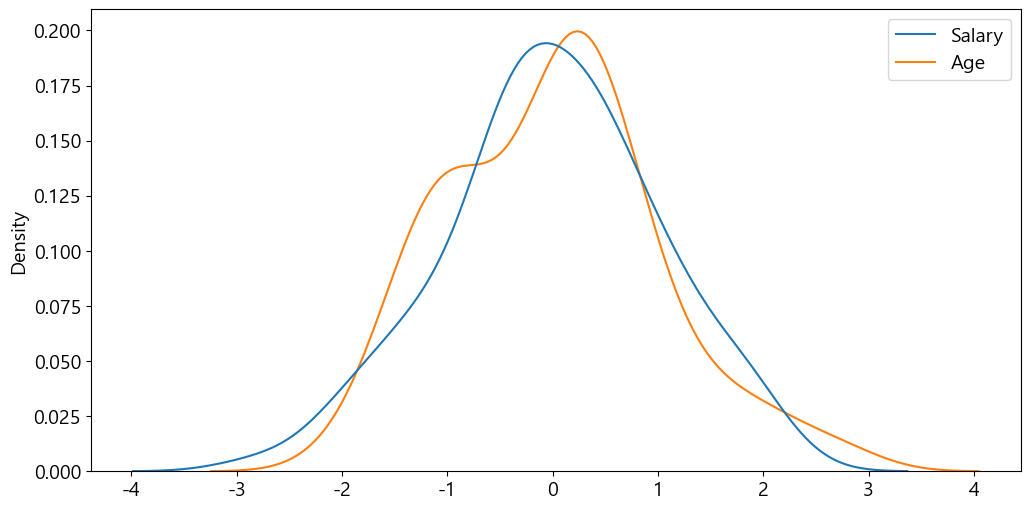

In [8]:
sns.kdeplot(data=df_std)

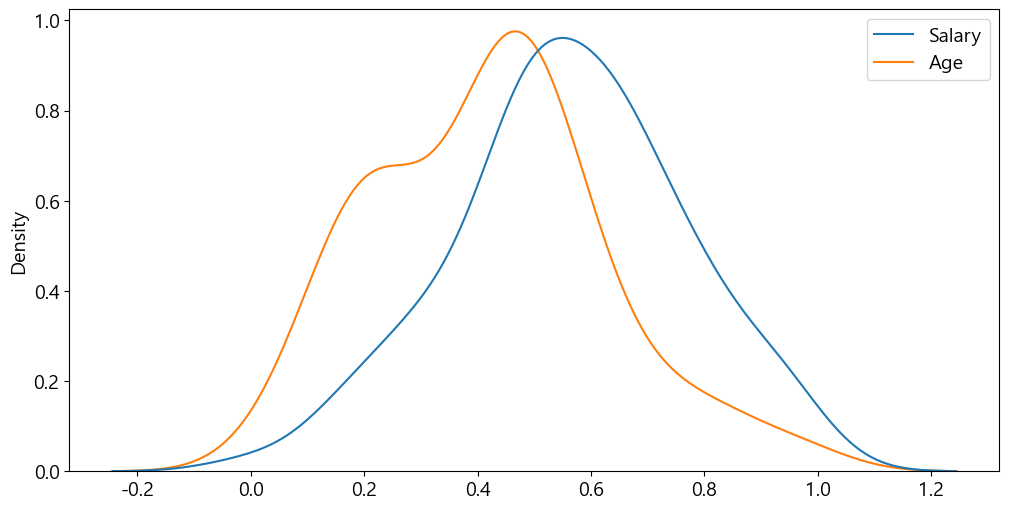

In [9]:
sns.kdeplot(df_minmax)
plt.show()

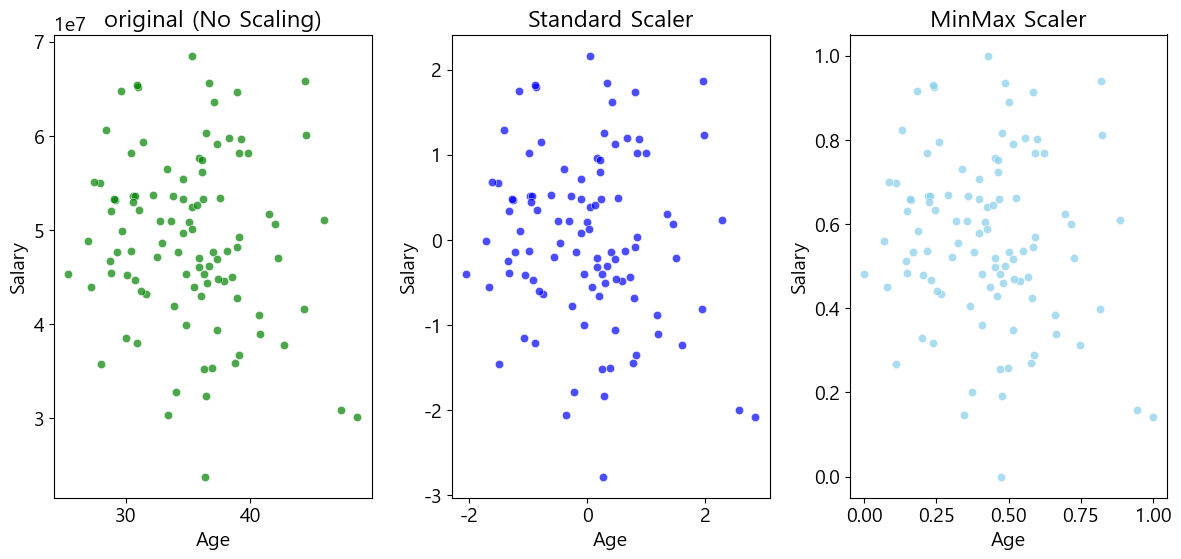

In [10]:
# 원본
plt.subplot(1,3,1)
sns.scatterplot(data=df, x='Age', y='Salary', color='green', alpha=0.7)
plt.title('original (No Scaling)')
plt.xlabel('Age')
plt.ylabel('Salary')

# Standard Scaler
plt.subplot(1,3,2)
sns.scatterplot(data=df_std, x='Age', y='Salary', color='blue', alpha=0.7)
plt.title('Standard Scaler')
plt.xlabel('Age')
plt.ylabel('Salary')

# MinMaxScaler
plt.subplot(1,3,3)
sns.scatterplot(data=df_minmax, x='Age', y='Salary', color='skyblue', alpha=0.7)
plt.title('MinMax Scaler')
plt.xlabel('Age')
plt.ylabel('Salary')

plt.tight_layout()
plt.show()

### 인코더
- 머신러닝은 숫자 데이터만 학습이 가능하다.
- 순서가 중요 하다면 : LabelEncoding
- 순서가 없다면 : One-Hot Encoding
- 순서가 중요한 데이터 : S, M, L
- 순서가 없는 데이터 : Red, Green

In [14]:
# 데이터 생성
data = {
    '사이즈' : ['S', 'M', 'L', 'XL', 'M'],
    '색상' : ['Red', 'Blue', 'Green', 'Blue', 'Red']
}

df = pd.DataFrame(data)
df

,사이즈,색상
0,S,Red
1,M,Blue
2,L,Green
3,XL,Blue
4,M,Red


In [17]:
# 순서가 중요한 데이터
# LabelEncoder 사용 : 알파벳 순서대로 0, 1, 2, 3...
encoder = LabelEncoder()
df['사이즈_Label'] = encoder.fit_transform(df['사이즈'])
df

,사이즈,색상,사이즈_Label
0,S,Red,2
1,M,Blue,1
2,L,Green,0
3,XL,Blue,3
4,M,Red,1


In [20]:
# LabelEncoder를 사용하게 되면 값의 순서가 어긋날 수 있다.
# 그래서 LabelEncoder를 사용하는 것 보다는 직접 설정해서 하는 것을 권장한다
size_mapping = {'S' : 0, 'M' : 1, 'L' : 2, 'XL' : 3}
df['사이즈_Map'] = df['사이즈'].map(size_mapping)
df

,사이즈,색상,사이즈_Label,사이즈_Map
0,S,Red,2,0
1,M,Blue,1,1
2,L,Green,0,2
3,XL,Blue,3,3
4,M,Red,1,1


In [26]:
# One Hot Encoding : 순서가 없을 때
# 색상(Red, Green, Blue)에 0,1,2를 부여했다면
# 컴퓨터는 Blue가 Red 보다 크구나~ 라고 생각해서 학습을 한다.
# 이럴 때 원핫 인코딩을 사용한다.
df_onehot = pd.get_dummies(df, columns=['색상'])
a1 = df_onehot[['색상_Blue','색상_Green','색상_Red']].astype(int)
df_onehot[['색상_Blue','색상_Green','색상_Red']] = a1
df_onehot['색상'] = df['색상']
df_onehot

,사이즈,사이즈_Label,사이즈_Map,색상_Blue,색상_Green,색상_Red,색상
0,S,2,0,0,0,1,Red
1,M,1,1,1,0,0,Blue
2,L,0,2,0,1,0,Green
3,XL,3,3,1,0,0,Blue
4,M,1,1,0,0,1,Red
